<a href="https://colab.research.google.com/github/honeylouluzon/Heart-Failure-Prediction-Model/blob/main/Guided_Project_Heart_Failure_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Guided Project: Predicting Heart Disease

##Introduction

The [World Health Organization (WHO)](https://www.who.int/health-topics/cardiovascular-diseases) estimates that 17.9 million people die from cardiovascular diseases (CVDs) every year.

There are multiple risk factors that could contribute to CVD in an individual, such as unhealthy diet, lack of physical activity, or mental illness. Identifying these risk factors early on could help prevent many premature deaths.

This [Guided Project](https://app.dataquest.io/c/134/m/ 740/guided-project%3A-predicting-heart-disease/1 ), we will use the [dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) that includes relevant information for each patient, such as their personal information and some medical data, including whether or not they have had heart disease before.

We will build a K-Nearest Neighbors classifier to accurately predict the likelihood of a patient having a heart disease in the future.

In [ ]:
#needed imports
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import random
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
import joblib
from sklearn.model_selection import GridSearchCV
from ipywidgets import interact, interactive, fixed, Layout
import ipywidgets as widgets
from IPython.display import display




In [ ]:
# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)

100%|██████████| 8.56k/8.56k [00:00<00:00, 12.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/fedesoriano/heart-failure-prediction/versions/1


##Dataset

In [ ]:
#loading the dataset
csv_file_path = os.path.join(path, 'heart.csv') # Assuming the CSV file is named 'heart.csv' inside the downloaded directory
data = pd.read_csv(csv_file_path)

In [ ]:
#show sample data
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


##Exploratory Data Analysis

###EDA: Dataset Features

In [ ]:
#dataset features
print(data.dtypes)
data.dtypes.value_counts()

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


,count
int64,6
object,5
float64,1


Our 12 features contain 1 decimal value (float64), 6 whole numbers (int64), and 5 object that may represent as text values as shown in the partial list above.

The dataset features are the following:

**Age**: age of the patient [years]  
**Sex**: sex of the patient [M: Male, F: Female]  
**ChestPainType**: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]  
**RestingBP**: resting blood pressure [mm Hg]  
**Cholesterol**: serum cholesterol [mm/dl]  
**FastingBS**: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]  
**RestingECG**: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]  
**MaxHR**: maximum heart rate achieved [Numeric value between 60 and 202]  
**ExerciseAngina**: exercise-induced angina [Y: Yes, N: No]  
**Oldpeak**: oldpeak = ST [Numeric value measured in depression]  
**ST_Slope**: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]  
**HeartDisease**: output class [1: heart disease, 0: Normal]  

###EDA: Descriptive Statistics

In [ ]:
#describing the dataset
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
#Number of missing values in each column
data.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


The dataset contains 918 rows for each column and there is no missing values in these fields.

**Observations to each field:**

1. Age
  - Range: 28 to 77 years old
  - Average age: 53.5 ± 9.43
  - Most patients are between 47 and 60 years old (middle 50%).

2. RestingBP (Resting Blood Pressure)
	- Min value is 0, which is likely an error or placeholder for missing data (since 0 BP is not realistic).
	- Average BP is about 132 ± 18.51, with most values between 120 and 140 (normal to slightly elevated range).

3. Cholesterol
	- Also has 0 as the minimum, which is likely invalid or missing.
	- Average is 198.8 ± 109.38, which is close to the borderline high cholesterol level.
	- Max is 603, which is unusually high.

4. FastingBS (Fasting Blood Sugar > 120 mg/dl)
	- Binary column (0 or 1).
	- Mean is 0.233 ± 0.42, meaning about 23% of patients have high fasting blood sugar.

5. MaxHR (Maximum Heart Rate Achieved)
	- Values range from 60 to 202.
	- Average is about 137 ± 25.46, which is a healthy sign during exercise.
	- Most people fall between 120 and 156 bpm.

6. Oldpeak (ST depression)
	- Measures ECG abnormalities during stress.
	- Ranges from -2.6 to 6.2 (negative values might mean baseline elevation).
	- Average is 0.89 ± 1.07, suggesting most have minimal ST depression.

7. HeartDisease
	- Binary target column (0 = No, 1 = Yes).
	- Mean is 0.553, so around 55.3% of patients have heart disease.
	- This implies a slight class imbalance toward heart disease cases.

###EDA: Categorical Data

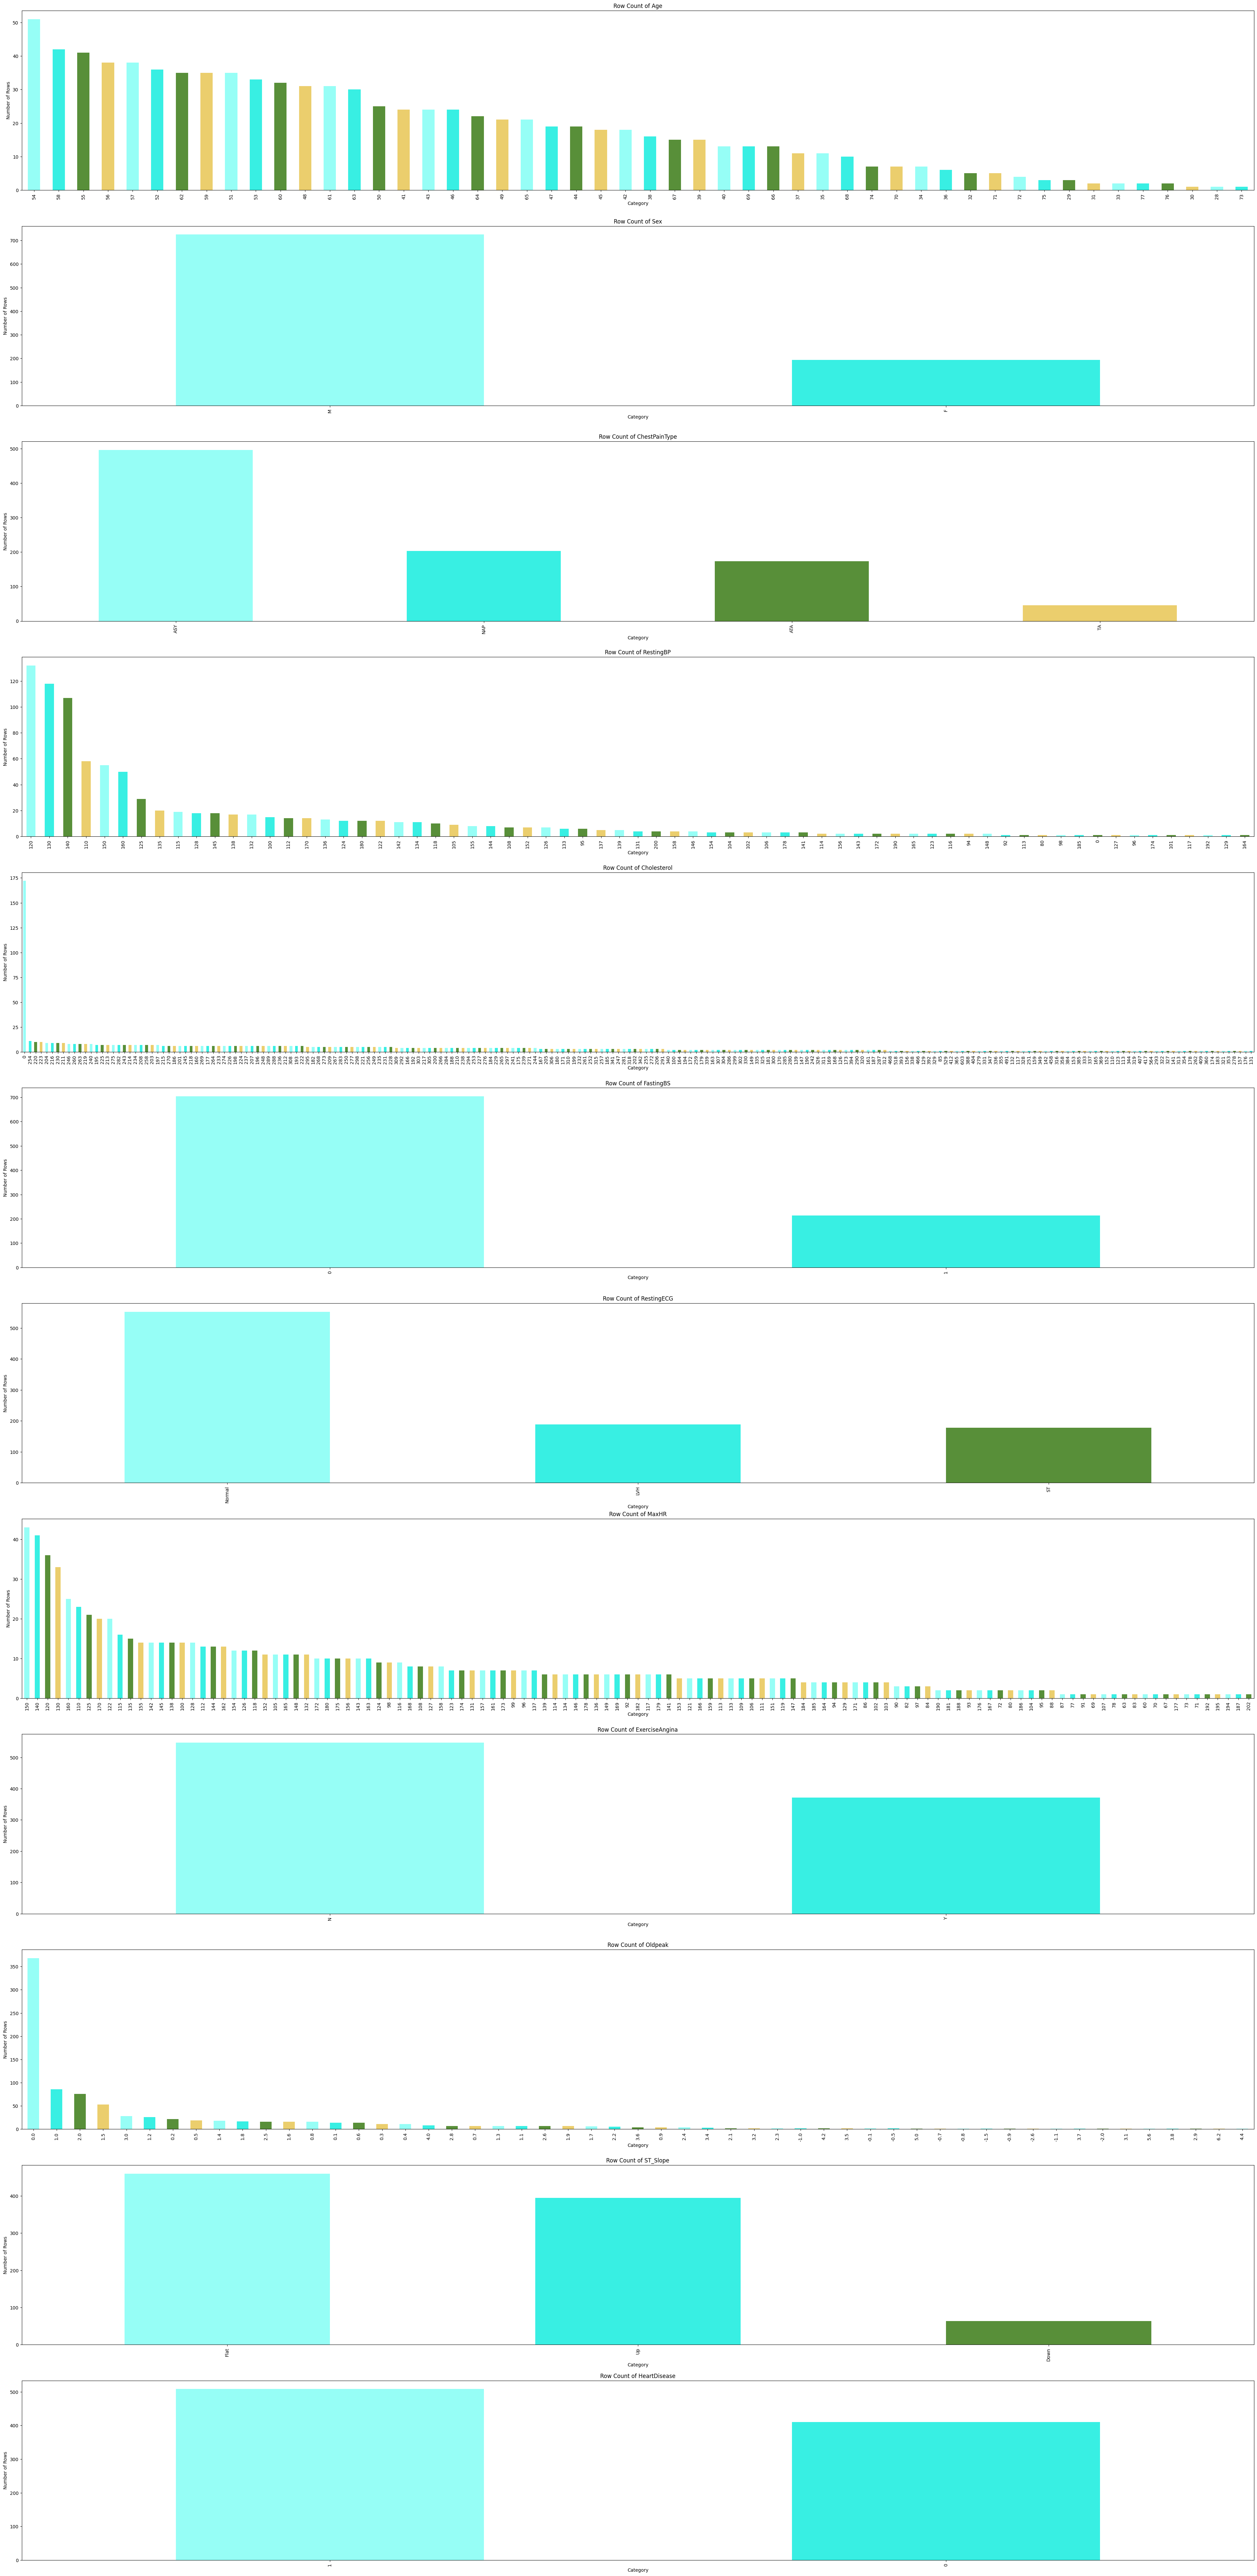

In [ ]:
#@title Categorized Per Column { display-mode: "form" }
counts={}

# Example: count rows per category in a column
for col in data.columns:
    counts[col]= data[col].value_counts()
#print(counts[col])
counts_series=pd.Series(counts)
#print(counts_series)

# Create subplots
fig, axes = plt.subplots(len(data.columns), 1, figsize=(len(data.columns)*4,100))
axes = axes.flatten()  # flatten if grid is >1x1

values = [10, 20, 15, 30]

colors = [(random.random(), random.random(), random.random())
          for _ in values]

# Create bar chart
for col in data.columns:
    #print(counts[col])
    index=data.columns.get_loc(col)
    counts_series[col].plot(kind='bar', ax=axes[index], color=colors)
    axes[index].set_xlabel("Category")
    axes[index].set_ylabel("Number of Rows")
    axes[index].set_title('Row Count of '+ col)

plt.show()

In the graph above, it shows that:
- In our record, mostly are aged around 50s with 54 years old is the highest count to be exact. Male is dominant with a counts of 725(79%) compare with female that is only 193 in all.
- 496 (54%) people with chestpain are Asymptomatic. It is also closer to the 410(44.7%) people recorded with no heart disease which is also shows that 86(9%) asymptomatic people could have heart disease but just not showing sign.
- If heart desease comes with exercise angina and not normal resting ECG, it is possible that 39(4%) people that is negative in exercise angina and 44(4.8%) with normal resting ECG could still have heart disease.
- There is an extreme higher count of zero cholesterol in the dataset around 172 people around 19% of the total count of people.
- Only 214(23%) is positive in FastingFBS, therefore, around half of the people in our dataset that have heart disease could not be positive to FastingFBS.

In [ ]:
#@title Categorized per Column and Heart Disease Condition{ display-mode: "form" }

data_w_heart_disease = data[data["HeartDisease"]==1]
data_wo_heart_disease = data[data["HeartDisease"]==0]
counts_whd={} #with heart disease
counts_wohd={} #without heart disease
# Example: count rows per category in a column
for col in data.columns:
    counts_whd[col]= data_w_heart_disease[col].value_counts()
    counts_wohd[col]= data_wo_heart_disease[col].value_counts()
#print(counts[col])
counts_series_whd=pd.Series(counts_whd)
counts_series_wohd=pd.Series(counts_wohd)
#print(counts_series)

# Create subplots
fig, axes = plt.subplots(len(data.columns)*2, 1, figsize=(len(data.columns)*5*2,100))
axes = axes.flatten()  # flatten if grid is >1x1

values = [10, 20, 15, 30]

colors = [(random.random(), random.random(), random.random())
          for _ in values]
index=0
# Create bar chart
for col in data.columns:
    #print("With Heart Disease")
    #print(counts_whd[col])
    counts_series_whd[col].plot(kind='bar', ax=axes[index], color=colors)
    axes[index].set_xlabel("Category")
    axes[index].set_ylabel("Number of Rows")
    axes[index].set_title(f'{index}: Row Count of '+ col +' with Heart Disease')

    index+=1
    #print("Without Heart Disease")
    #print(counts_wohd[col])
    counts_series_wohd[col].plot(kind='bar', ax=axes[index], color=colors)
    axes[index].set_xlabel ("Category")
    axes[index].set_ylabel("Number of Rows")
    axes[index].set_title(f'{index}: Row Count of '+ col +' without Heart Disease')

    index+=1

plt.show()

Based on the updated diagram above:
- chest pain doesn't shows relevant on having a heart disease. It even shows that 392 or 77% of people with heart disease in this dataset is asymptomatic or doesn't shows a sign.
- 90% of the people with heart disease which is about 458 people are male.
- 88% of the people that shows zero colesterol in our dataset appears to have a heart disease.

In [ ]:

male_over50_whd = data_w_heart_disease[(data_w_heart_disease['Sex']=='M') & (data_w_heart_disease['Age']>50)]
print(f'Male over 5O with Heart Disease is equal to {male_over50_whd['Sex'].count()}(37.5%)')

Male over 5O with Heart Disease is equal to 344(37.5%)


In [ ]:
median_age_whd = data_w_heart_disease['Age'].median()
print(f'Median of Age with Heart Disease is {int(median_age_whd)}')

Median of Age with Heart Disease is 57


###Data Cleaning

In [ ]:
#Count of Row with RestingBP=0
print(f'RestingBP = 0: {len(data[(data['RestingBP']==0)])} Rows')
dataCleaned = data.copy()
#Cleaned by replacing a median value
dataCleaned.loc[dataCleaned['RestingBP'] == 0, 'RestingBP'] = dataCleaned['RestingBP'].median()
print(f'[Cleaned]RestingBP = 0: {len(dataCleaned[dataCleaned['RestingBP']==0])} Rows')

RestingBP = 0: 1 Rows
[Cleaned]RestingBP = 0: 0 Rows


In [ ]:
#Count of Row with Cholesterol=0
print(f'Cholesterol = 0: {(data[(data['Cholesterol']==0)]).shape[0]} Rows')
#Cleaned by dropping rows
dataCleaned.drop(dataCleaned[dataCleaned['Cholesterol']==0].index, inplace=True)
print(f'[Cleaned]Cholesterol = 0: {(dataCleaned[(dataCleaned['Cholesterol']==0)]).shape[0]} Rows')

Cholesterol = 0: 172 Rows
[Cleaned]Cholesterol = 0: 0 Rows


In [ ]:
print(dataCleaned[dataCleaned['Oldpeak']>3].head())

     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
68    52   M           ASY        160          246          0         ST   
166   50   M           ASY        140          231          0         ST   
500   65   M           ASY        136          248          0     Normal   
521   61   M           ASY        120          282          0         ST   
537   74   M           ASY        150          258          1         ST   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
68      82              Y      4.0     Flat             1  
166    140              Y      5.0     Flat             1  
500    140              Y      4.0     Down             1  
521    135              Y      4.0     Down             1  
537    130              Y      4.0     Down             1  


###Feature Selection

In [ ]:
#Convert the Categorical Feature (One-Hot Encoding)
data_oneHot = pd.DataFrame()
oneHot_columns = ['RestingECG','ExerciseAngina','ST_Slope','HeartDisease','ChestPainType','Sex']
data_oneHot = pd.get_dummies(dataCleaned, columns=oneHot_columns, drop_first=True)
#data_oneHot.drop(['MaxHR','RestingBP','Age','FastingBS'], axis=1, inplace=True)
print(data_oneHot.head())




   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  RestingECG_Normal  \
0   40        140          289          0    172      0.0               True   
1   49        160          180          0    156      1.0               True   
2   37        130          283          0     98      0.0              False   
3   48        138          214          0    108      1.5               True   
4   54        150          195          0    122      0.0               True   

   RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  ST_Slope_Up  \
0          False             False          False         True   
1          False             False           True        False   
2           True             False          False         True   
3          False              True           True        False   
4          False             False          False         True   

   HeartDisease_1  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
0           False               True         

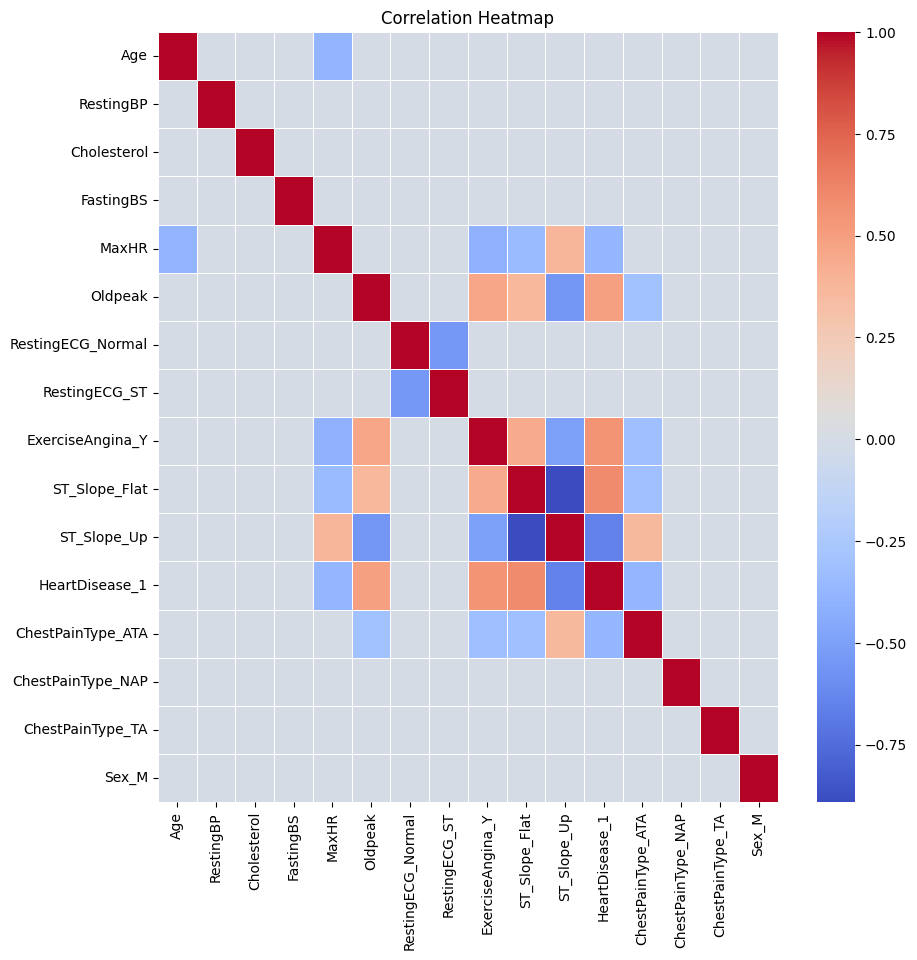

In [ ]:
#@title Heat Map { display-mode: "form" }

#Heat Map
corr_matrix = data_oneHot.corr()  # compute correlation between numeric columns

# Mask weak correlations
filtered_corr = corr_matrix.copy()
filtered_corr[abs(filtered_corr) < 0.3] = 0

plt.figure(figsize=(10, 10))  # optional: set figure size
sns.heatmap(filtered_corr,
            annot=False,       # show numbers on cells
            cmap='coolwarm',  # color palette
            fmt=".2f",        # format numbers
            linewidths=0.5,   # lines between cells
            cbar=True)        # show color bar
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Features (all columns except target)
X = data_oneHot.drop('HeartDisease_1', axis=1)

# Target column
y = data_oneHot['HeartDisease_1']

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

for col in X.columns:
    # Create k-NN classifier
    knn = KNeighborsClassifier(n_neighbors=3)  # You can change 3 to experiment

    # Use only the current feature for training
    X_train_feature = X_train[[col]]
    X_val_feature = X_val[[col]]

    # Fit the model
    knn.fit(X_train_feature, y_train)

    # Predict on validation set
    y_pred = knn.predict(X_val_feature)

    # Calculate accuracy
    acc = accuracy_score(y_val, y_pred)

    # Print the result
    print(f"Accuracy using feature '{col}': {acc:.4f}")

Accuracy using feature 'Age': 0.5600
Accuracy using feature 'RestingBP': 0.4867
Accuracy using feature 'Cholesterol': 0.4933
Accuracy using feature 'FastingBS': 0.5733
Accuracy using feature 'MaxHR': 0.6400
Accuracy using feature 'Oldpeak': 0.7600
Accuracy using feature 'RestingECG_Normal': 0.5600
Accuracy using feature 'RestingECG_ST': 0.5600
Accuracy using feature 'ExerciseAngina_Y': 0.7400
Accuracy using feature 'ST_Slope_Flat': 0.8200
Accuracy using feature 'ST_Slope_Up': 0.4733
Accuracy using feature 'ChestPainType_ATA': 0.4733
Accuracy using feature 'ChestPainType_NAP': 0.4733
Accuracy using feature 'ChestPainType_TA': 0.4733
Accuracy using feature 'Sex_M': 0.6667


*[Generated from ChatGPT using the accuracy rating result above]*

🟢 **Strong Predictors**

ST_Slope_Flat → 0.82
👉 Very strong single predictor
This likely means when ST slope is flat, it strongly relates to the target (probably heart disease presence).

Oldpeak → 0.76
👉 Also strong
Oldpeak measures ST depression during exercise → clinically meaningful → makes sense it predicts well.

ExerciseAngina_Y → 0.74
👉 Strong binary indicator
Exercise-induced chest pain is a known strong heart disease indicator.

Sex_M → 0.67
👉 Moderate to strong
Suggests gender has predictive signal in your dataset.

MaxHR → 0.64
👉 Decent continuous predictor

⸻

🟡 **Medium / Weak Predictors**

Age → 0.56
RestingECG_Normal / ST → 0.56
FastingBS → 0.57

These are slightly above random guessing (assuming binary classification baseline ≈ 0.50).

They help, but alone they’re not powerful.

⸻

🔴 **Weak / Almost No Signal Alone**

RestingBP → 0.49
Cholesterol → 0.49

These are basically random alone — but ⚠ important:
👉 Weak alone ≠ useless in combination.

Some features only work when combined with others.

⸻

🚩 **Interesting Case**

ST_Slope_Up → 0.47
Below 0.50 → possibly inverse relationship OR class imbalance effect.

ChestPainType (ATA, NAP, TA) → ~0.47 each
Individually weak — but together (full one-hot set), they might matter.

In [ ]:
# Create scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit + transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation data
X_val_scaled = scaler.transform(X_val)

In [ ]:
print(X_train_scaled.min())
print(X_train_scaled.max())
print(X_train_scaled.min(axis=0))
print(X_train_scaled.max(axis=0))
print(X_train_scaled)

0.0
1.0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[[0.58333333 0.44444444 0.34749035 ... 0.         0.         1.        ]
 [0.47916667 0.44444444 0.27027027 ... 0.         0.         0.        ]
 [0.5625     0.44444444 0.4034749  ... 0.         0.         0.        ]
 ...
 [0.33333333 0.25925926 0.27027027 ... 0.         0.         1.        ]
 [0.5        0.48148148 0.41505792 ... 0.         0.         1.        ]
 [0.22916667 0.53703704 0.59266409 ... 0.         0.         0.        ]]


In [ ]:
# Create model
knn = KNeighborsClassifier(n_neighbors=5)

# Fit model
knn.fit(X_train_scaled, y_train)

# Predict on validation set
y_val_pred = knn.predict(X_val_scaled)

# Evaluate accuracy
accuracy = accuracy_score(y_val, y_val_pred)
print("Validation Accuracy:", accuracy)


Validation Accuracy: 0.9066666666666666


**Note:**
The model
shows a good prediction rate of about 91%.

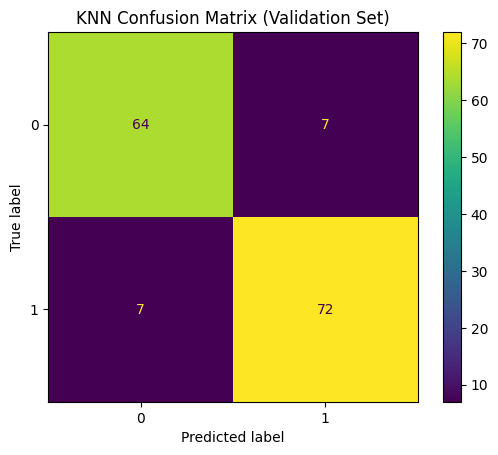

In [ ]:
#@title KNN Confusion Matrix { display-mode: "form" }

# Create confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("KNN Confusion Matrix (Validation Set)")
plt.show()

In [ ]:

# Model
knn = KNeighborsClassifier()

# Parameters
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Grid Search
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5
)

# Fit
grid_search.fit(X_train_scaled, y_train)

# Results
print("Best Accuracy:", grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)

Best Accuracy: 0.8523529411764705
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}


**Note:**
The model is performing well (85% accuracy), though not perfect.
	- Using 9 neighbors with uniform weighting and Euclidean distance gives the best balance between bias and variance on this dataset.

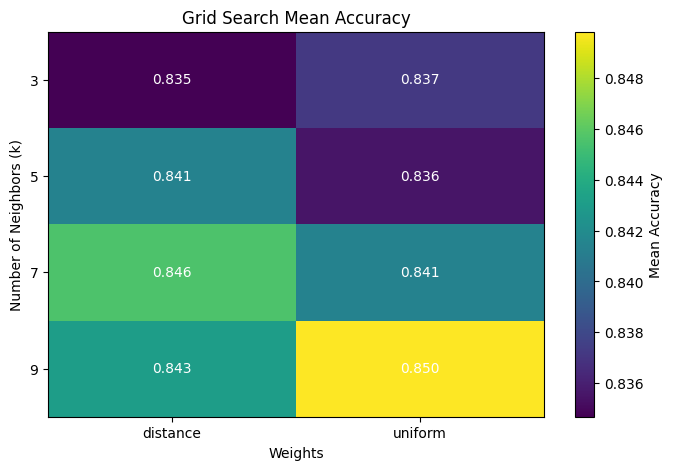

In [ ]:
#@title Grid Search Mean Accuracy { display-mode: "form" }

# Convert GridSearchCV results to DataFrame
results = pd.DataFrame(grid_search.cv_results_)

# Pivot table for easier plotting (example: n_neighbors vs mean test score)
pivot_table = results.pivot_table(
    values='mean_test_score',
    index='param_n_neighbors',
    columns='param_weights'
)

# Plot heatmap
plt.figure(figsize=(8, 5))
plt.title("Grid Search Mean Accuracy")
plt.xlabel("Weights")
plt.ylabel("Number of Neighbors (k)")

# Use imshow for heatmap
plt.imshow(pivot_table, cmap='viridis', aspect='auto')
plt.colorbar(label='Mean Accuracy')

# Add values on heatmap
for i, k in enumerate(pivot_table.index):
    for j, w in enumerate(pivot_table.columns):
        plt.text(j, i, f"{pivot_table.loc[k, w]:.3f}", ha='center', va='center', color='white')

plt.xticks(range(len(pivot_table.columns)), pivot_table.columns)
plt.yticks(range(len(pivot_table.index)), pivot_table.index)
plt.show()

In [ ]:
# 1️⃣ Scale the test set using the same scaler
X_val_scaled = scaler.transform(X_val)  # do NOT fit again!

# 2️⃣ Use the best estimator from GridSearchCV to predict
best_knn = grid_search.best_estimator_  # already trained on full training set
y_test_pred = best_knn.predict(X_val_scaled)

# 3️⃣ Calculate and print accuracy
test_accuracy = accuracy_score(y_val, y_val_pred)
print("Test Set Accuracy:", test_accuracy)

Test Set Accuracy: 0.9066666666666666


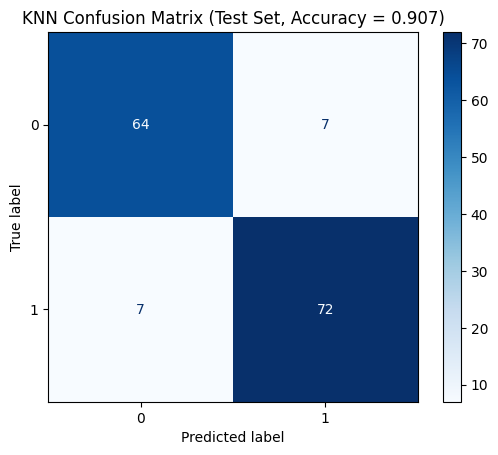

In [ ]:
#@title KNN Confusion Matrix { display-mode: "form" }
# Create confusion matrix
cm_test = confusion_matrix(y_val, y_val_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp.plot(cmap='Blues')  # optional: make it visually nicer

plt.title(f"KNN Confusion Matrix (Test Set, Accuracy = {test_accuracy:.3f})")
plt.show()

### Save the Final Model and Scaler

It's good practice to save your trained model and the scaler (which was used for preprocessing) so you can reuse them later without retraining. We'll use `joblib` for this.

In [ ]:
# Define filenames
model_filename = 'knn_heart_disease_model.joblib'
scaler_filename = 'min_max_scaler.joblib'

# Save the best KNN model
joblib.dump(grid_search.best_estimator_, model_filename)
print(f"Model saved to {model_filename}")

# Save the scaler
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved to {scaler_filename}")

Model saved to knn_heart_disease_model.joblib
Scaler saved to min_max_scaler.joblib


### Predict with New Data

This section demonstrates how to load the saved model and scaler, and then use `ipywidgets` to create a simple interactive form for users to input new patient data and get a prediction.

In [ ]:
#@title Prediction Form: Heart Disease { display-mode: "form" }

from ipywidgets import interact, interactive, fixed, Layout
import ipywidgets as widgets
from IPython.display import display

# Load the saved model and scaler
loaded_model = joblib.load('knn_heart_disease_model.joblib')
loaded_scaler = joblib.load('min_max_scaler.joblib')

# Get the feature names in the correct order as used during training
# This assumes X is still available and represents the original feature columns before scaling
feature_columns = X.columns.tolist()

# Create interactive widgets for each feature
def predict_heart_disease(
    Age,
    RestingBP,
    Cholesterol,
    FastingBS,
    MaxHR,
    Oldpeak,
    RestingECG_Normal,
    RestingECG_ST,
    ExerciseAngina_Y,
    ST_Slope_Flat,
    ST_Slope_Up,
    ChestPainType_ATA,
    ChestPainType_NAP,
    ChestPainType_TA,
    Sex_M
):
    # Create a DataFrame from the inputs, ensuring correct column order
    input_data = pd.DataFrame([[Age, RestingBP, Cholesterol, FastingBS, MaxHR, Oldpeak,
                                  RestingECG_Normal, RestingECG_ST, ExerciseAngina_Y,
                                  ST_Slope_Flat, ST_Slope_Up, ChestPainType_ATA,
                                  ChestPainType_NAP, ChestPainType_TA, Sex_M]],
                                columns=feature_columns)

    # Scale the input data using the loaded scaler
    scaled_input = loaded_scaler.transform(input_data)

    # Make prediction
    prediction = loaded_model.predict(scaled_input)
    prediction_proba = loaded_model.predict_proba(scaled_input)

    # Display result
    result_text = "Positive for Heart Disease" if prediction[0] else "Negative for Heart Disease"
    proba_positive = prediction_proba[0][1] * 100
    proba_negative = prediction_proba[0][0] * 100

    print(f"Prediction: {result_text}")
    print(f"Probability of Heart Disease: {proba_positive:.2f}%")
    print(f"Probability of No Heart Disease: {proba_negative:.2f}%")

# Define the widgets for each feature
# Use widgets appropriate for the data type and range of each feature
widgets_dict = {
    'Age': widgets.IntSlider(min=20, max=80, step=1, value=50, description='Age:', layout=Layout(width='auto')),
    'RestingBP': widgets.IntSlider(min=80, max=200, step=1, value=120, description='Resting BP:', layout=Layout(width='auto')),
    'Cholesterol': widgets.IntSlider(min=100, max=600, step=1, value=200, description='Cholesterol:', layout=Layout(width='auto')),
    'FastingBS': widgets.Checkbox(value=False, description='Fasting BS (>120):', layout=Layout(width='auto')),
    'MaxHR': widgets.IntSlider(min=60, max=202, step=1, value=140, description='Max HR:', layout=Layout(width='auto')),
    'Oldpeak': widgets.FloatSlider(min=-2.0, max=6.0, step=0.1, value=0.0, description='Oldpeak:', layout=Layout(width='auto')),
    'RestingECG_Normal': widgets.Checkbox(value=True, description='Resting ECG: Normal', layout=Layout(width='auto')),
    'RestingECG_ST': widgets.Checkbox(value=False, description='Resting ECG: ST Abnormality', layout=Layout(width='auto')),
    'ExerciseAngina_Y': widgets.Checkbox(value=False, description='Exercise Angina:', layout=Layout(width='auto')),
    'ST_Slope_Flat': widgets.Checkbox(value=True, description='ST Slope: Flat', layout=Layout(width='auto')),
    'ST_Slope_Up': widgets.Checkbox(value=False, description='ST Slope: Up', layout=Layout(width='auto')),
    'ChestPainType_ATA': widgets.Checkbox(value=False, description='Chest Pain: ATA', layout=Layout(width='auto')),
    'ChestPainType_NAP': widgets.Checkbox(value=False, description='Chest Pain: NAP', layout=Layout(width='auto')),
    'ChestPainType_TA': widgets.Checkbox(value=False, description='Chest Pain: TA', layout=Layout(width='auto')),
    'Sex_M': widgets.Checkbox(value=True, description='Sex: Male', layout=Layout(width='auto'))
}

# Create the interactive UI
interactive_widget = interactive(predict_heart_disease, **widgets_dict)
display(interactive_widget)

interactive(children=(IntSlider(value=50, description='Age:', layout=Layout(width='auto'), max=80, min=20), In…